In [3]:
from dotenv import load_dotenv
import os 
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
print(AZURE_OPENAI_API_KEY[:10])
print(MODEL_NAME)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_ENDPOINT'] = os.getenv('LANGCHAIN_ENDPOINT')
os.environ['LANGCHAIN_TRACING_V2'] = 'true' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'RAG'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    if len(os.getenv('LANGCHAIN_API_KEY')) > 0:
        print('랭스미스로 추적 중입니다 :', os.getenv('LANGSMITH_API_KEY')[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

43b13g4OZS
gpt-5-mini
랭스미스로 추적 중입니다 : lsv2_pt_24


## Adaptive RAG

llm이 입력에 따라 적절한 도구를 선택할 수 있게하는 adaptive 방법을 연습해봅시다.

In [4]:
import os, glob
from typing import TypedDict, Literal, List, Annotated

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph.message import add_messages

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.documents import Document
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser

### 1. State

해당 상태에는 

- 대화의 맥락을 이해할 수 있게하는 message
- 두 분기 중 하나를 선택하게 하는 route
- RAG를 위한 context와 refs

In [7]:
class GState(TypedDict, total=False):
    messages: Annotated[List[BaseMessage], add_messages]   # 대화 이력 누적
    route: Literal["common","rag"]                         # 라우팅 결과
    context: str                                           # RAG 컨텍스트
    refs: List[str]                                        # RAG 출처 ["file.pdf p.N", ...]

### 2. 데이터 로더 및 저장, 리트리버 설정

In [8]:
from langchain_openai import AzureOpenAIEmbeddings
emb = AzureOpenAIEmbeddings(
    model=EMB_MODEL_NAME,                      
    api_key=AZURE_OPENAI_EMB_API_KEY,
    azure_endpoint=EMB_END_POINT,
    api_version="2024-08-01-preview"
)

def build_vectordb(pdf_glob: str, chunk_size=800, chunk_overlap=120) -> InMemoryVectorStore:
    
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    docs = []
    for path in glob.glob(pdf_glob):
        loader = PyMuPDFLoader(path)   
        docs.extend(loader.load())

    splits = splitter.split_documents(docs) 
    return InMemoryVectorStore.from_documents(splits, embedding=emb)

VSTORE = build_vectordb("pdf/*.pdf")
retriever = VSTORE.as_retriever(search_kwargs={"k": 10}) 

### 3. 다양한 용도의 LLM


In [9]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.1,
)

### 4. Message에서 최신 질문을 추출하는 함수

message에는 human과 ai가 반복적으로 저장이됩니다. 

가장 마지막 index의 message가 최신 기록입니다. 

In [10]:
def last_user_text(messages: List[BaseMessage]) -> str:
    for m in reversed(messages):
        if isinstance(m, HumanMessage):
            return m.content
    return messages[-1].content if messages else ""

### 5. Router

일반적인 챗봇으로 동작할지 아니면 문서를 기반으로 정확한 정보를 줘야하는지 지능적으로 판단

In [22]:
router_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "너는 사용자의 질문이 이용자 약관을 검토해야 하는 '엄밀한 근거(약관/조항/정의/의무/해지/요금/계약 등)'를 필요로 하면 rag, "
     "그 외 통신 일반 상식/조언이면 common을 출력한다. 출력은 반드시 'rag' 또는 'common' 한 단어만 말해야한다."),
    ("human", "질의: {q}")
])

def route_node(state: GState) -> GState:
    """RAG/일반 대화 모드 라우팅"""
    q = last_user_text(state["messages"])
    out = (router_prompt | llm | StrOutputParser()).invoke({"q": q}).strip().lower()
    mode = "rag" if out.startswith("rag") else "common"  
    return {"route": mode}


### 6. 리트리버

검색과 함께 근거를 제시할 ref도 metadata에서 추출한다.

In [23]:
def retrieve_node(state: GState) -> GState:
    """RAG 컨텍스트 및 레퍼런스 추출"""
    q = last_user_text(state["messages"])
    docs = retriever.invoke(q)                        

    # 컨텍스트 텍스트
    context = "\n\n---\n\n".join(d.page_content for d in docs)

    # 레퍼런스 추출 (파일명 + 페이지)
    refs: List[str] = []
    
    seen = set()
    for d in docs:
        meta = d.metadata or {}
        src = meta.get("source") or meta.get("file_path") or meta.get("path")
        page = meta.get("page")
        if page is None:
            page = meta.get("page_number")
        disp_page = (page + 1) if isinstance(page, int) and page >= 0 else None
        if src:
            fname = os.path.basename(src)
            ref = f"{fname} p.{disp_page}" if disp_page is not None else f"{fname}"
            key = (fname, disp_page)
            if key not in seen:
                seen.add(key)
                refs.append(ref)

    return {"context": context, "refs": refs}

### 7. 이용 약관 상담 RAG 

In [24]:
no_ref = "해당 질문에 대한 자료를 찾을 수 없습니다. 담당자에게 문의 바랍니다."

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 사실을 근거로 대답하는 RAG이다. 아래 컨텍스트의 내용만을 근거로 답하라. "
               f"근거가 부족하면 '{no_ref}'이라고만 답하라.\n\n"
               "컨텍스트:\n{context}"),
    MessagesPlaceholder("messages"),   
])

def answer_rag(state: GState) -> GState:
    """RAG 모드 엄밀한 답변 생성"""
    out = (rag_prompt | llm | StrOutputParser()).invoke({
        "messages": state["messages"],
        "context": state.get("context","")
    }).strip()

    # 레퍼런스 붙이기
    refs = state.get("refs", [])
    if out.strip() == no_ref:
        refs = []
    if refs:
        out = out.rstrip() + "\n\n[출처] " + "; ".join(refs[:3])

    return {"messages": [AIMessage(content=out)]}

### 8. 가벼운 대화 챗봇

In [25]:
common_prompt = ChatPromptTemplate.from_messages([
    ("system", "한국어로 간결하고 명확하고 친절하게, 비즈니스 톤으로 답하라. 가벼운 질문에는 편안한 어조를 허용한다."),
    MessagesPlaceholder("messages"),   
])

def answer_without_rag(state: GState) -> GState:
    """RAG 없이 일반 대화 모드"""
    out = (common_prompt | llm | StrOutputParser()).invoke({
        "messages": state["messages"]
    })
    return {"messages": [AIMessage(content=out.strip())]}

### 9. 랭그래프 구성

In [26]:
graph = StateGraph(GState)
graph.add_node("route", route_node)
graph.add_node("retrieve", retrieve_node)
graph.add_node("answer_without_rag", answer_without_rag)
graph.add_node("answer_rag", answer_rag)

graph.set_entry_point("route")
graph.add_conditional_edges(
    "route", #이 노드 다음으로 
    lambda s: s["route"], # state route의 값을 넣어줌
    {"common": "answer_without_rag", "rag": "retrieve"}
)
graph.add_edge("retrieve", "answer_rag")
graph.add_edge("answer_without_rag", END)
graph.add_edge("answer_rag", END)

In [29]:
memory = MemorySaver()
app = graph.compile(checkpointer=memory) # multi-turn 을 위한 checkpointer 설정

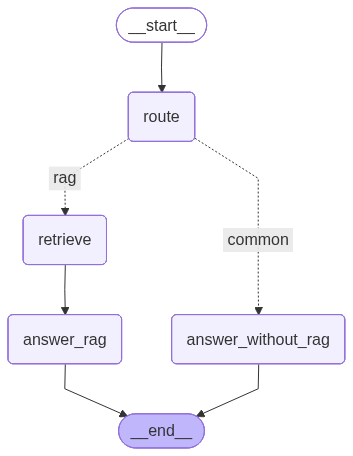

In [30]:
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

### 10. 실행 함수

In [33]:
def run(sid: str, text: str) -> str:
    """thread_id(sid)와 사용자 입력(text)만 넘겨 간단히 한 턴 실행."""
    res = app.invoke(
        {"messages": [HumanMessage(content=text)]},
        config={"configurable": {"thread_id": sid}},
    )
    return res["messages"][-1].content  # message의 최종 item이 AI의 답변

In [39]:
sid = "user_003"

print(run(sid, "내 이름은 김진태야")) 
print("\n---")
print(run(sid, "내 이름이 뭐라고 했는지 기억해?")) 
print("\n---")
print(run(sid, "가장 저렴한 요금제는 뭐야?"))  
print("\n---")
print(run(sid, "GiGA WiFi Buddy 요금제에 대해서 설명해줘."))  
print("\n---")
print(run(sid, "더 간단하게 설명해줘"))  
print("\n---")
## <--이 대답을 주의깊게 봅시다.
print(run(sid, "이번에 Ultra 초가성비 무제한 7G 요금제가 나왔다는데 어떤거야?")) 

네, 김진태님! 다시 뵙게 되어 반갑습니다. 무엇을 도와드릴까요?

---
네, 김진태님이라고 기억하고 있습니다. 언제든 편하게 문의해 주세요!

---
김진태님, 가장 저렴한 요금제는 GiGA WiFi Buddy 3년 약정 요금제로, 월 1,100원부터 이용 가능합니다. 필요하신 요금제 종류나 서비스에 따라 더 자세히 안내해 드릴 수 있으니 말씀해 주세요!

---
GiGA WiFi Buddy 요금제는 약정 기간에 따라 요금이 다르며, 다음과 같습니다.

- 무약정: 월 8,800원
- 1년 약정: 월 7,150원
- 2년 약정: 월 5,500원
- 3년 약정: 월 1,100원

특징:
- 해지 시까지 무상 A/S가 제공됩니다.
- 임대료는 해지 시까지 부과되며, 3년 이후에는 무상임대가 아닙니다.
- 해지 시 AP는 반납해야 합니다.
- 해당 상품의 약정은 인터넷 약정 기준으로 제공됩니다.
- GiGA WiFi Buddy를 사용하는 KT 인터넷의 경우, “인터넷 와이드”라고 명명합니다.

[출처] 인터넷서비스_이용약관.pdf p.139; 인터넷서비스_이용약관.pdf p.84; 인터넷서비스_이용약관.pdf p.142

---
네, 김진태님. GiGA WiFi Buddy는 약정 기간에 따라 월 1,100원부터 이용 가능한 무선 인터넷 임대 서비스입니다. 약정이 길수록 요금이 저렴해지고, 해지할 때는 장비를 반납해야 합니다. 도움이 필요하시면 언제든 말씀해 주세요!

---
김진태님, Ultra 초가성비 무제한 7G 요금제는 월 7,000원대에 7GB 데이터를 기본으로 제공하며, 이후에도 속도 제한이 걸리지만 계속 사용할 수 있는 가성비 좋은 요금제입니다. 데이터 사용량이 많지 않으면서 저렴한 요금제를 찾으신다면 적합한 선택입니다. 더 궁금한 점 있으시면 알려주세요!


In [36]:
print(run("user_002", "내 이름이 뭐라고 했는지 기억해?")) 

죄송하지만, 이전 대화에서 이름을 알려주지 않으셔서 기억하지 못합니다. 알려주시면 기억하는 데 도움이 될 것 같습니다.


### 다른 워크플로우로 구현해본 adaptive 예제

In [ ]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.1,
)
emb = AzureOpenAIEmbeddings(
    model=EMB_MODEL_NAME,                      
    api_key=AZURE_OPENAI_EMB_API_KEY,
    azure_endpoint=EMB_END_POINT,
    api_version="2024-08-01-preview"
)
from typing import TypedDict, List, Optional
import os, glob
import re
from langgraph.graph import StateGraph, START, END

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_core.documents import Document
from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver

def load_terms_from_pdf_folder(folder: str = "pdf") -> List[Document]:
    pdf_paths = sorted(glob.glob(os.path.join(folder, "*이용약관*.pdf")))
    if not pdf_paths:
        raise FileNotFoundError(f"'{folder}' 폴더에 pdf 파일이 없습니다.")

    print(f'파일 리스트 : {pdf_paths}')
    docs: List[Document] = []
    for p in pdf_paths:
        loader = PyMuPDFLoader(p, mode="page")  
        docs.extend(loader.load())

    # 청크 분할
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800,         
        chunk_overlap=120,      
        separators=["\n\n", "\n", " ", ""],
    )
    chunks = splitter.split_documents(docs)
    return chunks

TERMS_CHUNKS = load_terms_from_pdf_folder("pdf")
print(f'청크 수: {len(TERMS_CHUNKS)}')

VS = FAISS.from_documents(TERMS_CHUNKS, embedding=emb)
retriever = VS.as_retriever(search_kwargs={"k": 4})

from langchain_tavily import TavilySearch
web_tool = TavilySearch(max_results=5)

class State(TypedDict):
    question: str
    passages: List[Document]
    rag_answer: Optional[str]
    rag_sufficient: Optional[bool]
    user_confirmation: Optional[str]
    web_context: Optional[str]
    final_answer: Optional[str]

    history: List[dict] 

def retrieve(state: State) -> State:
    q = state["question"]
    docs = retriever.invoke(q)
    return {"passages": docs}

LOCAL_ANSWER_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "너는 엄격한 RAG기반 통신사의 상담원이다. 반드시 제공된 '약관' 정보 안에서만 답한다. "
     "근거 조항/문장을 인용(가능하면 페이지/섹션 포함)하고, "
     "가능한 약관 안에서 대답하고 근거가 불충분하면 **반드시** 마지막에 다음 문장인 '<rag_result>insufficient</rag_result>'을 추가하라."
     "약관을 통한 대답이 충분한지에 대한 판단은 어느정도만 되어도 괜찮으므로 최소한의 정보만 있다면 충분하다고 판단하고 불충분으로 과하게 판단하지 말라."
     "요약+인용 형식으로 간결하게 답하고 없는 건 억지로 만들지 말라."),
    ("user",
     "질문: {question}\n\n[약관]\n{context}\n\n"
     )
])

def answer_from_rag(state: State) -> State:
    
    passages = state.get("passages", [])
    ctx = "\n\n".join([
        f"[meta: {d.metadata.get('source','?')} p{d.metadata.get('page', '?')}] {d.page_content}"
        for d in passages
    ]) or "(없음)"
    

    answer = (LOCAL_ANSWER_PROMPT | llm | StrOutputParser()).invoke({"question": state["question"], "context": ctx})
    print(re.sub(r'<rag_result>.*?</rag_result>', '', answer))
    
    sufficient = not ("<rag_result>" in answer)

    new_hist = list(state.get("history", []))
    new_hist.append({"role": "assistant", "content": f"[RAG 답변]\n{answer}"})

    return {
        "rag_answer": answer,
        "rag_sufficient": sufficient,
        "history": new_hist
    }

def ask_user_confirmation(state: State) -> State:
    
    user_confirmation = input("인터넷에서 검색할까요? (yes/no) > ").strip().lower()
    if user_confirmation in ["y", "yes", '네', '예', 'ok', '확인', '응', '그래', '네', 'agree', 'ㅛ', 'ㅛㄷㄴ', 'ㅛㄸㄴ', 'ㅇㅇ']:
        return {"user_confirmation": True}
    else:
        return {"user_confirmation": False}

WEB_ANSWER_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "너는 웹 검색 보조자다. 약관에서 찾지 못한 질문에 대한 답을 제공된 웹검색 요약을 사용해 답하고, "
     "출처와 함께 정리하여 답하되, 없는 건 억지로 만들지 말라."
     "약관에서 찾은 답이 아니라면 주의할 점과 상황에 대한 설명을 추가하라."
     "만약 웹 검색 요약이 없다면 약관에서 찾은 답을 그대로 사용하라."
     "필요하다면 유저에게 관련된 다른 질문을 제시하라."),
    ("user",
     "질문: {question}\n\n[약관 임시답]\n{rag_answer}\n\n[웹 검색 요약]\n{web_context}\n\n"
     "답변:")
])
    
def web_search_and_answer(state: State) -> State:
    
    q = state["question"]
    results = web_tool.invoke({"query": q})
    
    lines = []
    for r in results['results']:
        url = r.get("url") or r.get("source") or ""
        title = r.get("title") or ""
        snippet = (r.get("content") or r.get("snippet") or "")[:400]
        lines.append(f"<title>{title}</title>\n<url>{url}</url>\n<snippet>{snippet}</snippet>")
    web_ctx = "\n".join(lines) if lines else "(검색 결과 없음)"

    final_answer = (WEB_ANSWER_PROMPT | llm | StrOutputParser()).invoke({"question": q, "rag_answer": state.get("rag_answer",""), "web_context": web_ctx})

    new_hist = list(state.get("history", []))
    new_hist.append({"role": "assistant", "content": f"[웹 검색 대답]\n{final_answer}"})
    return {"web_context": web_ctx, "final_answer": final_answer, "history": new_hist}

def decide_after_rag(state: State) -> str:
    if state.get("rag_sufficient"):
        return "end"
    else:
        return "ask_web_search"

def decide_after_ask_user(state: State) -> str:
    if state.get("user_confirmation"):
        return "search_web"
    else:
        return "end"
    
workflow = StateGraph(State)
workflow.add_node("retrieve", retrieve)
workflow.add_node("answer_from_rag", answer_from_rag)
workflow.add_node("ask_user", ask_user_confirmation)
workflow.add_node("web_search", web_search_and_answer)

workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "answer_from_rag")
workflow.add_conditional_edges(
    "answer_from_rag", decide_after_rag,
    {
        "end": END,
        "ask_web_search": "ask_user",
    }
)
workflow.add_conditional_edges(
    "ask_user", decide_after_ask_user,
    {
        "search_web": "web_search",
        "end": END,
    }
)
workflow.add_edge("web_search", END)

USE_MULTI_TURN = False
if USE_MULTI_TURN:
    checkpointer = InMemorySaver()
    graph = workflow.compile(checkpointer=checkpointer)
else:
    graph = workflow.compile()
graph

In [ ]:
def run(question: str, use_id: str = "user-1"):
    cfg = {"configurable": {"thread_id": use_id}}

    final_state = graph.invoke({"question": question}, cfg)
    if final_state.get("final_answer"):
        print("===[웹 검색을 추가로 진행한 최종 답변입니다.]===\n\n")
        print(final_state['final_answer'])

In [ ]:
run("Giga wifi 요금제에 대해서 알려줘")

## Iterative RAG

이번 예제 llm이 한 답변을 평가하고 만약 충분하지 못할 경우 query를 재작성해서 다시 질의하는 것을 반복하는 RAG 모델입니다.

In [41]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore 

### 1. State 정의

State의 구성은 다음과 같습니다.

1. State (S)
    - origin_q: 사용자의 원질문(보존)
    - refine_q: 검색 최적화를 위한 재작성 질문 --> refine이 업데이트
    - context: 검색된 컨텍스트(문서 본문들) --> retrieve가 벡터DB로부터 추출
    - step: 반복 횟수(예산/루프 제한) --> refine될 때마다 1씩 추가
    - answer: 현재 초안 or 최종 답 --> 반복중에는 draft가 답을 작성하고 최종 마지막에 finalize가 작성
    - done: 종료 여부 플래그 --> judge가 반복 수행할지 판단

In [42]:
# State 정의
class S(TypedDict):
    origin_q: str
    refine_q: str
    context: List[str]
    step: int
    answer: str
    iter_limit: int
    done: bool

### 2. Data Split & Store & Retriver

이번 예제에서는 이해를 돕기 위해 가짜로 작성한 dummy doc을 사용하겠습니다.

만약 필요하다면 이 부분의 loader만 추가한다면 외부 문서를 활용한 RAG가 될 것입니다.

In [43]:
# 더미 문서
dummy_docs = [
    Document(page_content="주식회사 KJT는 최근 파란색 사과의 재배를 성공했다.", metadata={"source": "news"}),
    Document(page_content="파랑새는 희망을 상징하지만 파란색 사과는 그것에 더한 의미가 있다. 바로 발전과 혁신을 상징한다.", metadata={"source": "wiki"}),
    Document(page_content="곳 (주)KJT는 무지개 사과를 개발할 계획이라고 김진태 연구원은 발표했다.", metadata={"source": "news"}),
    Document(page_content="보라색 사과에는 단백질이 풍부하다.", metadata={"source": "news"}),
    Document(page_content="연구팀은 붉은빛 무늬가 나타나는 검은 사과의 유전자 구조를 해독했다고 밝혔다.", metadata={"source": "news"}),
    Document(page_content="은빛 사과는 최근 패션업계에서 스타 이춘자씨가 주얼리 소재로 활용해 인기를 끌었다.", metadata={"source": "magazine"}),
    Document(page_content="청록색 사과는 바다에서 재배되는데 해양 미네랄이 풍부해 건강식품으로 각광받고 있다.", metadata={"source": "news"}),
    Document(page_content="투명 사과는 전설 속에서 금지된 열매로 묘사되지만, 최근 재현 실험이 진행 중이다.", metadata={"source": "wiki"}),
]

splitter = RecursiveCharacterTextSplitter(chunk_size=100, chunk_overlap=10, separators=["\n\n", "\n", "  ", " "])
splits = splitter.split_documents(dummy_docs)

#  벡터스토어
emb = AzureOpenAIEmbeddings(
    model=EMB_MODEL_NAME,                      
    api_key=AZURE_OPENAI_EMB_API_KEY,
    azure_endpoint=EMB_END_POINT,
    api_version="2024-08-01-preview"
)
vectordb = InMemoryVectorStore.from_documents(splits, embedding=emb)
retriever = vectordb.as_retriever(search_type="similarity", search_kwargs={"k": 2})


### 3. LLM 

생성 및 지능적 판단을 위해 사용할 공통적인 llm을 선언합니다.

In [44]:
llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.2,
)

### 4. Retrieve

State의 쿼리에 대해 DB에서 정보를 검색하는 부분입니다. 

In [45]:
def retrieve(state: S) -> S:
    """
    질의에 대한 문서(context)를 VectorDB에서 검색
    context 업데이트
    """
    if state["step"] == 0:
        q = state["origin_q"]
    else:
        q = state["refine_q"]
    docs = retriever.invoke(q)
    state["context"] = [d.page_content for d in docs]
    return state

####  5. Draft

주어진 정보를 취합해서 초안을 생성하는 RAG 부분입니다. 

In [46]:
draft_prompt = ChatPromptTemplate.from_messages([
    ("system","아래 컨텍스트만 근거로 간결히 답하라."),
    ("human","질문: {refine_q}\n\n컨텍스트:\n{context}")
])

def draft(state: S) -> S:
    
    # 초회라면 refine_q를 origin_q로 맞춤
    if state["step"]==0:
        state["refine_q"] = state["origin_q"]

    out = (draft_prompt | llm | StrOutputParser()).invoke({
        "refine_q": state["refine_q"],
        "context": "\n\n".join(state["context"])
    })
    state["answer"] = out
    return state

### 6. Judge

초안을 검토해서 재작성 여부를 판단하는 노드입니다.

무한히 반복되는 것을 방지하기 위해 step의 크기를 보고 done을 강제로 설정합니다.

In [47]:
def judge(state: S) -> S:

    # 최대 반복 제한 n회
    if state["step"] >= state["iter_limit"]:
        state["done"] = True
        return state
    
    prompt = ChatPromptTemplate.from_template(
        "다음 답변이 질문에 대해 충분한가? 전혀 틀렸으면 no, 적당히 내용이 포함되어 있으면 yes 만 답하라. (yes/no)\n"
        "반드시 yes 또는 no로만 대답하라.\n"
        "질문: {refine_q}\n답변: {answer}"
    )
    
    chain = prompt | llm | StrOutputParser()

    j = chain.invoke({
        "refine_q": state["refine_q"],
        "answer": state["answer"]
    })
    
    state['done'] = "yes" in j
    return state


### 7. Refine

judge에 의해 결과가 좋지 못하다고 판단되면 쿼리를 수정한다. 

그리고 다시 루프가 원래대로 돌아가므로 step을 하나 올린다.

In [48]:
def refine(state: S) -> S:
    prompt = ChatPromptTemplate.from_template(
        "다음 질문을 더 잘 검색되도록 재작성하거나 필요한 경우 1개 서브질문으로 바꿔라. 문장 하나로만 작성하라.\n"
        "원질문: {refine_q}\n현재답: {answer}\n컨텍스트(일부): {context}"
    )

    chain = prompt | llm | StrOutputParser()
    r = chain.invoke({
        "refine_q": state["refine_q"],
        "answer": state["answer"],
        "context": "\n\n".join(state["context"])
    })
    state["refine_q"] = r
    state["step"] += 1
    return state

### 8. Finalize

만약 답변이 충분하거나 iter가 충분히 반복되었다면 초안을 토대로 최종적인 답만 간결하게 추출한다.

In [49]:
final_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "너는 최종 답안을 출력한다. '묻는 말만' 답을 완성된 문장으로 간결·정확하게 답하라. "
     "사족/메타발언/면책문구 금지. 컨텍스트 밖 추론 금지. "
     "근거가 부족하면 '근거가 부족해 답할 수 없습니다.'이라고만 답하라."),
    ("human","질문: {origin_q}\n초안: {draft}\n컨텍스트:\n{context}")
])


def finalize(state: S) -> S:

    out = (final_prompt | llm | StrOutputParser()).invoke({
        "origin_q": state["origin_q"],
        "draft": state["answer"],
        "context": "\n\n".join(state["context"])
    })
    state["answer"] = out
    return state

### 9. 그래프 구성

만들어진 노드를 edge로 연결하여 lang graph를 compile한다.

entry와 end를 주의하여 작성

조건부 분기에 done을 통해 어떤 node로 갈지를 지정한다.


In [50]:
g = StateGraph(S)
g.add_node("retrieve", retrieve)
g.add_node("draft", draft)
g.add_node("judge", judge)
g.add_node("refine", refine)
g.add_node("finalize", finalize)

g.set_entry_point("retrieve")  # 시작 노드 지정
g.add_edge("retrieve","draft")
g.add_edge("draft","judge")
g.add_conditional_edges(
    "judge", # judge가 분기를 판단
    lambda s: "finalize" if s["done"] else "refine", # done=True면 finalize, False면 refine
    {"finalize": "finalize", "refine": "refine"} # 각 조건에 맞는 다음 노드 지정
)
g.add_edge("refine","retrieve")
g.add_edge("finalize", END)

app = g.compile()

### 그래프 구조 확인

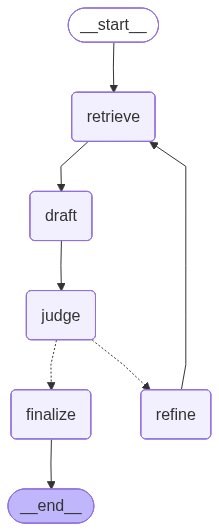

In [51]:
# plot graph
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [52]:
# ---- 실행 예시
if __name__ == "__main__":
    result = app.invoke({
        "origin_q":"파란색 사과의 상징은?", 
        "refine_q": "", 
        "context":[], 
        "step":0, 
        "answer":"", 
        "iter_limit":3,
        "done":False
    })
    print(result["answer"])

파란색 사과는 발전과 혁신을 상징한다.


In [53]:
init_state = {"origin_q": "파란색 사과를 개발한 회사는 어디인가?", "refine_q": "", "context": [], "step":0, "answer":"", "iter_limit": 3, "done":False}
result = app.invoke(init_state)
print(f'iteration : {result["step"]} step')  # 몇 번 반복했는지
print(f'refined q : {result["refine_q"]}')  # 수정된 질문
print(f'context : {result["context"]}')  # 찾은 원문
print('\n--- answer ---\n')
print(result['answer'])  # 최종 답변 출력

iteration : 0 step
refined q : 파란색 사과를 개발한 회사는 어디인가?
context : ['주식회사 KJT는 최근 파란색 사과의 재배를 성공했다.', '파랑새는 희망을 상징하지만 파란색 사과는 그것에 더한 의미가 있다. 바로 발전과 혁신을 상징한다.']

--- answer ---

파란색 사과를 개발한 회사는 주식회사 KJT이다.


In [54]:
init = {"origin_q":"파란색 사과의 상징은?","refine_q":"", "context":[], "step":0, "answer":"", "iter_limit": 3, "done":False}

for idx, step_update in enumerate(app.stream(init, stream_mode="updates")):
    print(f"[iter {idx}] -- {step_update}")

[iter 0] -- {'retrieve': {'origin_q': '파란색 사과의 상징은?', 'refine_q': '', 'context': ['파랑새는 희망을 상징하지만 파란색 사과는 그것에 더한 의미가 있다. 바로 발전과 혁신을 상징한다.', '보라색 사과에는 단백질이 풍부하다.'], 'step': 0, 'answer': '', 'iter_limit': 3, 'done': False}}
[iter 1] -- {'draft': {'origin_q': '파란색 사과의 상징은?', 'refine_q': '파란색 사과의 상징은?', 'context': ['파랑새는 희망을 상징하지만 파란색 사과는 그것에 더한 의미가 있다. 바로 발전과 혁신을 상징한다.', '보라색 사과에는 단백질이 풍부하다.'], 'step': 0, 'answer': '파란색 사과는 발전과 혁신을 상징한다.', 'iter_limit': 3, 'done': False}}
[iter 2] -- {'judge': {'origin_q': '파란색 사과의 상징은?', 'refine_q': '파란색 사과의 상징은?', 'context': ['파랑새는 희망을 상징하지만 파란색 사과는 그것에 더한 의미가 있다. 바로 발전과 혁신을 상징한다.', '보라색 사과에는 단백질이 풍부하다.'], 'step': 0, 'answer': '파란색 사과는 발전과 혁신을 상징한다.', 'iter_limit': 3, 'done': True}}
[iter 3] -- {'finalize': {'origin_q': '파란색 사과의 상징은?', 'refine_q': '파란색 사과의 상징은?', 'context': ['파랑새는 희망을 상징하지만 파란색 사과는 그것에 더한 의미가 있다. 바로 발전과 혁신을 상징한다.', '보라색 사과에는 단백질이 풍부하다.'], 'step': 0, 'answer': '파란색 사과는 발전과 혁신을 상징한다.', 'iter_limit': 3, 'done': True}}


In [58]:
init = {"origin_q":"색깔 사과!","refine_q":"", "context":[], "step":0, "answer":"", "iter_limit": 3, "done":False}

for idx, step_update in enumerate(app.stream(init, stream_mode="updates")):
    print(f"[iter {idx}] -- {step_update}")

# ✅ 수정: f-string 내부의 딕셔너리 키는 큰따옴표 사용
print(f'\n\n{step_update["finalize"]["answer"]}')

[iter 0] -- {'retrieve': {'origin_q': '색깔 사과!', 'refine_q': '', 'context': ['보라색 사과에는 단백질이 풍부하다.', '은빛 사과는 최근 패션업계에서 스타 이춘자씨가 주얼리 소재로 활용해 인기를 끌었다.'], 'step': 0, 'answer': '', 'iter_limit': 3, 'done': False}}
[iter 1] -- {'draft': {'origin_q': '색깔 사과!', 'refine_q': '색깔 사과!', 'context': ['보라색 사과에는 단백질이 풍부하다.', '은빛 사과는 최근 패션업계에서 스타 이춘자씨가 주얼리 소재로 활용해 인기를 끌었다.'], 'step': 0, 'answer': '보라색 사과는 단백질이 풍부하고, 은빛 사과는 주얼리 소재로 인기가 있습니다.', 'iter_limit': 3, 'done': False}}
[iter 2] -- {'judge': {'origin_q': '색깔 사과!', 'refine_q': '색깔 사과!', 'context': ['보라색 사과에는 단백질이 풍부하다.', '은빛 사과는 최근 패션업계에서 스타 이춘자씨가 주얼리 소재로 활용해 인기를 끌었다.'], 'step': 0, 'answer': '보라색 사과는 단백질이 풍부하고, 은빛 사과는 주얼리 소재로 인기가 있습니다.', 'iter_limit': 3, 'done': False}}
[iter 3] -- {'refine': {'origin_q': '색깔 사과!', 'refine_q': '보라색 사과의 영양 성분과 은빛 사과가 주얼리 소재로 인기를 끄는 이유는 무엇인가요?', 'context': ['보라색 사과에는 단백질이 풍부하다.', '은빛 사과는 최근 패션업계에서 스타 이춘자씨가 주얼리 소재로 활용해 인기를 끌었다.'], 'step': 1, 'answer': '보라색 사과는 단백질이 풍부하고, 은빛 사과는 주얼리 소재로 인기가 있습니다.', 'iter_limit': 3, 'don

In [60]:
def chat(session_id: str, question: str) -> str:

    result = app.invoke(
        {
            "origin_q": question,
            "refine_q": "",
            "context": [],
            "step": 0,
            "answer": "",
            "iter_limit": 3,
            "done": False
        },
        config={"configurable": {"thread_id": session_id}},
    )
    return result["answer"]

### Practice

- 프롬프트를 변경해봅시다.
- 리트리버의 유사도 검색 방법을 mmr로 변경해보고 리트리버의 검색 결과가 어떻게 변하는지 로그를 찍어봅시다. 
- Iterative와 Adaptive를 결합해봅시다.